# 09 - XGBoost Explainability

## Objective

This notebook explains the final XGBoost model saved by Notebook 08. It:

- loads the fitted model, preprocessing pipeline, and frozen threshold;
- creates a leakage-safe November-December explanation sample;
- calculates TreeSHAP values directly from the production model;
- reports global importance, average direction, and one local explanation;
- saves compact SHAP artifacts for the downstream notebooks and dashboard.

Notebook 09 does not retrain the model, select features, change the threshold, or use a surrogate model. SHAP describes how the model formed its predictions; it does not establish causal relationships.


## Load Project Configuration and Libraries


In [9]:
from __future__ import annotations

import importlib.util
import io
import json
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from databricks.sdk import WorkspaceClient
from dotenv import dotenv_values
from pyspark.sql import DataFrame
from pyspark.sql import functions as F
from pyspark.sql import types as T

bootstrap = Path.cwd() / "notebooks" / "import_path.py"
if not bootstrap.is_file():
    bootstrap = Path.cwd() / "import_path.py"

spec = importlib.util.spec_from_file_location("import_path", bootstrap)
import_path = importlib.util.module_from_spec(spec)
spec.loader.exec_module(import_path)

from config import project_config as cfg

databricks_profile = os.getenv(
    "DATABRICKS_CONFIG_PROFILE",
    "capstone-serverless",
)

api_env_candidates = [
    Path.cwd() / "api" / ".env",
    Path.cwd().parent / "api" / ".env",
]
api_env_path = next((path for path in api_env_candidates if path.is_file()), None)
api_credentials = dotenv_values(api_env_path) if api_env_path else {}

LOCAL_DATABRICKS_HOST = str(
    api_credentials.get("DATABRICKS_SERVER_HOSTNAME", "")
).strip()
LOCAL_DATABRICKS_TOKEN = str(
    api_credentials.get("DATABRICKS_ACCESS_TOKEN", "")
).strip()
if LOCAL_DATABRICKS_HOST and not LOCAL_DATABRICKS_HOST.startswith("http"):
    LOCAL_DATABRICKS_HOST = f"https://{LOCAL_DATABRICKS_HOST}"

try:
    spark
except NameError:
    from databricks.connect import DatabricksSession

    session_builder = DatabricksSession.builder.serverless()
    if LOCAL_DATABRICKS_HOST and LOCAL_DATABRICKS_TOKEN:
        session_builder = session_builder.host(LOCAL_DATABRICKS_HOST).token(
            LOCAL_DATABRICKS_TOKEN
        )
    else:
        session_builder = session_builder.profile(databricks_profile)
    spark = session_builder.getOrCreate()

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)

print("Project configuration, Spark session, and SHAP libraries loaded.")


Project configuration, Spark session, and SHAP libraries loaded.


## Load and Validate the Final Model Bundle

Notebook 08 saves one bundle containing the fitted XGBoost model, fitted preprocessing pipeline, input-feature lists, and frozen decision threshold. Loading that complete bundle guarantees that explanations use the same transformations and model used for the final holdout evaluation.


In [10]:
def artifact_client() -> WorkspaceClient:
    try:
        dbutils
    except NameError:
        if LOCAL_DATABRICKS_HOST and LOCAL_DATABRICKS_TOKEN:
            return WorkspaceClient(
                host=LOCAL_DATABRICKS_HOST,
                token=LOCAL_DATABRICKS_TOKEN,
                auth_type="pat",
            )
        return WorkspaceClient(profile=databricks_profile)
    return WorkspaceClient()


client = artifact_client()


def download_artifact(path: str) -> bytes:
    response = client.files.download(path)
    if response.contents is None:
        raise RuntimeError(f"Artifact is empty: {path}")
    return response.contents.read()


model_bundle = joblib.load(
    io.BytesIO(download_artifact(cfg.SELECTED_MODEL_BUNDLE_PATH))
)
model_metadata = json.loads(
    download_artifact(cfg.SELECTED_MODEL_METADATA_PATH).decode("utf-8")
)

required_bundle_keys = {
    "model",
    "preprocessor",
    "model_name",
    "decision_threshold",
    "categorical_features",
    "numerical_features",
    "target",
}
missing_bundle_keys = sorted(required_bundle_keys - set(model_bundle))
if missing_bundle_keys:
    raise ValueError(
        f"Final model bundle is missing keys: {missing_bundle_keys}"
    )

FINAL_MODEL = model_bundle["model"]
PREPROCESSOR = model_bundle["preprocessor"]
MODEL_NAME = str(model_bundle["model_name"])
DECISION_THRESHOLD = float(model_bundle["decision_threshold"])
CATEGORICAL_COLUMNS = list(model_bundle["categorical_features"])
NUMERICAL_COLUMNS = list(model_bundle["numerical_features"])
TARGET_COLUMN = str(model_bundle["target"])
MODEL_COLUMNS = CATEGORICAL_COLUMNS + NUMERICAL_COLUMNS
DATE_COLUMN = cfg.FLIGHT_DATE_COLUMN

if MODEL_NAME != "XGBoost":
    raise ValueError(f"Notebook 09 requires XGBoost; found {MODEL_NAME}.")
if not 0.0 < DECISION_THRESHOLD < 1.0:
    raise ValueError(
        f"Invalid frozen threshold: {DECISION_THRESHOLD}"
    )
if TARGET_COLUMN != cfg.TARGET_COLUMN:
    raise ValueError(
        f"Bundle target {TARGET_COLUMN} does not match {cfg.TARGET_COLUMN}."
    )
if not np.isclose(
    DECISION_THRESHOLD,
    float(model_metadata["decision_threshold"]),
):
    raise ValueError("Bundle and metadata thresholds do not match.")

print(f"Final model: {MODEL_NAME}")
print(f"Configuration: {model_metadata['configuration_id']}")
print(f"Frozen threshold: {DECISION_THRESHOLD:.2f}")
print(f"Model inputs: {len(MODEL_COLUMNS)}")
print("The final model is loaded without retraining.")


Final model: XGBoost
Configuration: baseline-reference
Frozen threshold: 0.20
Model inputs: 19
The final model is loaded without retraining.


## Create a Leakage-Safe Explanation Sample

Explanations are calculated on a reproducible sample from the November-December holdout period. The four historical delay rates are learned only from January-October outcomes. Therefore, holdout outcomes do not contribute to their own predictors.


In [11]:
FEATURE_TABLE = cfg.FEATURES_TABLE

if not spark.catalog.tableExists(FEATURE_TABLE):
    raise RuntimeError(
        f"Required table '{FEATURE_TABLE}' was not found. "
        "Run Notebook 06 before continuing."
    )

df_features: DataFrame = spark.table(FEATURE_TABLE)

required_source_columns = (
    set(
        MODEL_COLUMNS
        + list(cfg.MODELING_JOIN_KEY_COLUMNS)
        + [TARGET_COLUMN, DATE_COLUMN]
    )
    - set(cfg.MODEL_HISTORICAL_RATE_COLUMNS)
)
missing_source_columns = sorted(
    required_source_columns - set(df_features.columns)
)
if missing_source_columns:
    raise ValueError(
        f"Feature table is missing columns: {missing_source_columns}"
    )
if not isinstance(df_features.schema[DATE_COLUMN].dataType, T.DateType):
    raise TypeError(f"{DATE_COLUMN} must be a Spark date column.")

df_training_history = df_features.filter(
    F.col(DATE_COLUMN) <= F.lit(cfg.VALIDATION_END_DATE)
)
df_holdout = df_features.filter(
    F.col(DATE_COLUMN).between(
        F.lit(cfg.TEST_START_DATE), F.lit(cfg.TEST_END_DATE)
    )
)

invalid_holdout_targets = df_holdout.filter(
    F.col(TARGET_COLUMN).isNull()
    | ~F.col(TARGET_COLUMN).isin(0.0, 1.0)
).count()
if invalid_holdout_targets:
    raise ValueError(
        f"Holdout contains {invalid_holdout_targets:,} invalid targets."
    )

print("Final training history: January-October 2025")
print("Explanation period: November-December 2025")


Final training history: January-October 2025
Explanation period: November-December 2025


In [12]:
HISTORY_SPECS = [
    ("AIRLINE_HIST_DELAY_RATE", [cfg.AIRLINE_COLUMN]),
    ("ORIGIN_HIST_DELAY_RATE", [cfg.ORIGIN_COLUMN]),
    ("DEST_HIST_DELAY_RATE", [cfg.DESTINATION_COLUMN]),
    (
        "ROUTE_HIST_DELAY_RATE",
        [cfg.ORIGIN_COLUMN, cfg.DESTINATION_COLUMN],
    ),
]
SMOOTHING = float(cfg.HISTORICAL_SMOOTHING_STRENGTH)


def attach_fixed_history(
    training_history: DataFrame,
    rows_to_score: DataFrame,
) -> DataFrame:
    global_rate = float(
        training_history.agg(
            F.avg(TARGET_COLUMN).alias("RATE")
        ).first()["RATE"]
    )
    scored = rows_to_score

    for output_column, group_columns in HISTORY_SPECS:
        group_history = (
            training_history.groupBy(*group_columns)
            .agg(
                F.count("*").alias("HIST_FLIGHTS"),
                F.sum(TARGET_COLUMN).alias("HIST_DELAYS"),
            )
            .withColumn(
                output_column,
                (
                    F.col("HIST_DELAYS")
                    + SMOOTHING * F.lit(global_rate)
                )
                /
                (
                    F.col("HIST_FLIGHTS")
                    + F.lit(SMOOTHING)
                ),
            )
            .select(*group_columns, output_column)
        )
        scored = scored.join(
            group_history,
            group_columns,
            "left",
        ).fillna({output_column: global_rate})

    return scored


def uniform_sample(
    frame: DataFrame,
    maximum_rows: int,
    seed: int,
) -> DataFrame:
    row_count = frame.count()
    if row_count <= maximum_rows:
        return frame
    fraction = min(1.0, maximum_rows / row_count * 1.08)
    return frame.sample(False, fraction, seed).limit(maximum_rows)


sampled_holdout = uniform_sample(
    df_holdout,
    cfg.SHAP_SAMPLE_SIZE,
    cfg.RANDOM_SEED + 9000,
)
holdout_with_history = attach_fixed_history(
    df_training_history,
    sampled_holdout,
)

identifier_columns = list(
    dict.fromkeys(cfg.MODELING_JOIN_KEY_COLUMNS)
)
explanation_columns = list(
    dict.fromkeys(
        identifier_columns + MODEL_COLUMNS + [TARGET_COLUMN]
    )
)
explanation_pdf = holdout_with_history.select(
    *explanation_columns
).toPandas()

encoded_explanation = PREPROCESSOR.transform(
    explanation_pdf[MODEL_COLUMNS]
)
actual_labels = (
    explanation_pdf[TARGET_COLUMN].astype(int).to_numpy()
)
delay_probabilities = FINAL_MODEL.predict_proba(
    encoded_explanation
)[:, 1]
predicted_labels = (
    delay_probabilities >= DECISION_THRESHOLD
).astype(int)

print(f"Explanation rows: {len(explanation_pdf):,}")
print(f"Encoded features: {encoded_explanation.shape[1]:,}")
print(f"Observed delay rate: {actual_labels.mean():.2%}")
print(f"Alert rate at {DECISION_THRESHOLD:.2f}: {predicted_labels.mean():.2%}")


Explanation rows: 20,000
Encoded features: 725
Observed delay rate: 23.41%
Alert rate at 0.20: 47.62%


## Calculate TreeSHAP Values

TreeSHAP explains the fitted XGBoost model directly, so a separate surrogate is unnecessary. The one-hot encoded SHAP contributions are grouped back into the 19 original input variables. Positive values push a prediction toward greater delay risk; negative values push it toward lower risk.

XGBoost TreeSHAP values are expressed in the model's raw score (log-odds) rather than probability percentage points.


In [13]:
explainer = shap.TreeExplainer(FINAL_MODEL)
shap_explanation = explainer(
    encoded_explanation,
    check_additivity=False,
)
encoded_shap_values = np.asarray(shap_explanation.values)

if encoded_shap_values.ndim == 3:
    encoded_shap_values = encoded_shap_values[:, :, -1]
if encoded_shap_values.shape[1] != encoded_explanation.shape[1]:
    raise ValueError(
        "SHAP feature count does not match the encoded model matrix."
    )

encoded_feature_names = [
    str(name) for name in PREPROCESSOR.get_feature_names_out()
]


def original_feature(encoded_name: str) -> str:
    transformer, raw_name = encoded_name.split("__", 1)
    if transformer == "numerical":
        return raw_name
    for column in sorted(
        CATEGORICAL_COLUMNS,
        key=len,
        reverse=True,
    ):
        if raw_name == column or raw_name.startswith(f"{column}_"):
            return column
    raise ValueError(
        f"Unable to map encoded feature to an input column: {encoded_name}"
    )


encoded_to_original = [
    original_feature(name) for name in encoded_feature_names
]
aggregated_shap_values = np.zeros(
    (encoded_shap_values.shape[0], len(MODEL_COLUMNS)),
    dtype=float,
)

for feature_index, feature_column in enumerate(MODEL_COLUMNS):
    encoded_indexes = [
        index
        for index, original_column in enumerate(encoded_to_original)
        if original_column == feature_column
    ]
    if not encoded_indexes:
        raise ValueError(
            f"No encoded columns were found for {feature_column}."
        )
    aggregated_shap_values[:, feature_index] = (
        encoded_shap_values[:, encoded_indexes].sum(axis=1)
    )

FEATURE_LABELS = {
    cfg.AIRLINE_COLUMN: "Airline",
    cfg.ORIGIN_COLUMN: "Origin airport",
    cfg.DESTINATION_COLUMN: "Destination airport",
    cfg.SEASON_COLUMN: "Season",
    cfg.TIME_OF_DAY_COLUMN: "Time of day",
    cfg.FLIGHT_DISTANCE_CATEGORY_COLUMN: "Distance category",
    cfg.MONTH_COLUMN: "Month",
    cfg.DAY_OF_WEEK_COLUMN: "Day of week",
    cfg.DISTANCE_COLUMN: "Flight distance",
    cfg.SCHEDULED_ELAPSED_TIME_COLUMN: "Scheduled elapsed time",
    cfg.DEP_HOUR_COLUMN: "Scheduled departure hour",
    cfg.DEP_MINUTE_COLUMN: "Scheduled departure minute",
    cfg.ARR_HOUR_COLUMN: "Scheduled arrival hour",
    cfg.ARR_MINUTE_COLUMN: "Scheduled arrival minute",
    cfg.IS_WEEKEND_COLUMN: "Weekend indicator",
    "AIRLINE_HIST_DELAY_RATE": "Historical airline delay rate",
    "ORIGIN_HIST_DELAY_RATE": "Historical origin delay rate",
    "DEST_HIST_DELAY_RATE": "Historical destination delay rate",
    "ROUTE_HIST_DELAY_RATE": "Historical route delay rate",
}

feature_importance = pd.DataFrame(
    {
        "Feature": [
            FEATURE_LABELS.get(column, column)
            for column in MODEL_COLUMNS
        ],
        "MeanAbsSHAP": np.abs(aggregated_shap_values).mean(axis=0),
        "FeatureColumn": MODEL_COLUMNS,
    }
).sort_values("MeanAbsSHAP", ascending=False, ignore_index=True)

mean_shap = aggregated_shap_values.mean(axis=0)
direction_of_effects = pd.DataFrame(
    {
        "Feature": [
            FEATURE_LABELS.get(column, column)
            for column in MODEL_COLUMNS
        ],
        "Mean_SHAP": mean_shap,
        "Mean_Absolute_SHAP": np.abs(
            aggregated_shap_values
        ).mean(axis=0),
        "Effect_Direction": np.where(
            mean_shap > 0,
            "Increases predicted delay risk on average",
            np.where(
                mean_shap < 0,
                "Decreases predicted delay risk on average",
                "Neutral on average",
            ),
        ),
        "FeatureColumn": MODEL_COLUMNS,
    }
).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False,
    ignore_index=True,
)

print("TreeSHAP values calculated directly from the final XGBoost model.")


TreeSHAP values calculated directly from the final XGBoost model.


## Global Model Explanation

Mean absolute SHAP measures how strongly each input influences predictions across the explanation sample. A larger value means the feature is more influential; it does not indicate causation or whether the influence is always positive.


,Feature,MeanAbsSHAP,FeatureColumn
0,Scheduled arrival hour,0.240294,ARR_HOUR
1,Scheduled departure hour,0.186167,DEP_HOUR
2,Historical route delay rate,0.185757,ROUTE_HIST_DELAY_RATE
3,Day of week,0.124431,DAY_OF_WEEK
4,Month,0.084590,MONTH
5,Airline,0.082130,OP_UNIQUE_CARRIER
6,Season,0.074006,SEASON
7,Destination airport,0.073427,DEST
8,Origin airport,0.044007,ORIGIN
9,Historical airline delay rate,0.043660,AIRLINE_HIST_DELAY_RATE


,Feature,Mean_SHAP,Mean_Absolute_SHAP,Effect_Direction,FeatureColumn
0,Scheduled arrival hour,-0.041871,0.240294,Decreases predicted delay risk on average,ARR_HOUR
1,Scheduled departure hour,-0.021140,0.186167,Decreases predicted delay risk on average,DEP_HOUR
2,Historical route delay rate,0.021352,0.185757,Increases predicted delay risk on average,ROUTE_HIST_DELAY_RATE
3,Day of week,-0.027275,0.124431,Decreases predicted delay risk on average,DAY_OF_WEEK
4,Month,-0.066929,0.084590,Decreases predicted delay risk on average,MONTH
5,Airline,-0.000788,0.082130,Decreases predicted delay risk on average,OP_UNIQUE_CARRIER
6,Season,-0.050244,0.074006,Decreases predicted delay risk on average,SEASON
7,Destination airport,-0.012089,0.073427,Decreases predicted delay risk on average,DEST
8,Origin airport,-0.006985,0.044007,Decreases predicted delay risk on average,ORIGIN
9,Historical airline delay rate,0.003706,0.043660,Increases predicted delay risk on average,AIRLINE_HIST_DELAY_RATE


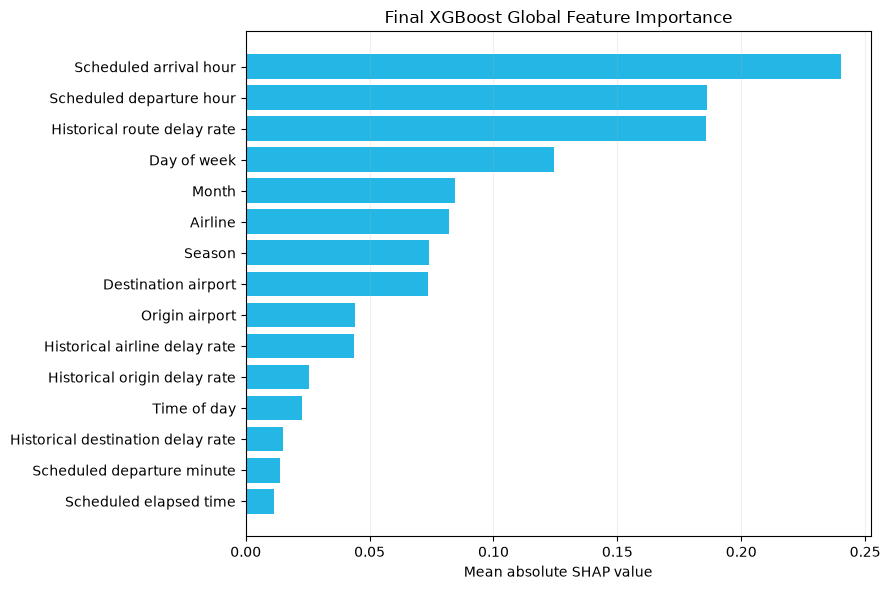

In [14]:
display(feature_importance)
display(direction_of_effects)

plot_data = (
    feature_importance.head(15)
    .sort_values("MeanAbsSHAP", ascending=True)
)
fig, axis = plt.subplots(figsize=(9, 6))
axis.barh(
    plot_data["Feature"],
    plot_data["MeanAbsSHAP"],
    color="#24b7e5",
)
axis.set_title("Final XGBoost Global Feature Importance")
axis.set_xlabel("Mean absolute SHAP value")
axis.set_ylabel("")
axis.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()


## Local Flight Explanation

The local example uses the highest-risk flight in the reproducible explanation sample. Its SHAP contributions show which variables increased or decreased that specific prediction. The actual class is displayed only because this is an offline holdout analysis; it would be unknown when scoring a future flight.


,FlightDate,Airline,FlightNumber,Origin,Destination,DelayProbability,DecisionThreshold,PredictedClass,ActualClass
0,2025-11-20,YX,5746,LGA,BOS,0.73479,0.2,1,0


,Feature,FeatureColumn,SHAPValue,AbsoluteSHAP
0,Destination airport,DEST,0.376752,0.376752
1,Scheduled arrival hour,ARR_HOUR,0.373409,0.373409
2,Origin airport,ORIGIN,0.366313,0.366313
3,Month,MONTH,0.320514,0.320514
4,Scheduled departure hour,DEP_HOUR,0.239417,0.239417
5,Historical origin delay rate,ORIGIN_HIST_DELAY_RATE,0.199221,0.199221
6,Historical route delay rate,ROUTE_HIST_DELAY_RATE,0.142346,0.142346
7,Season,SEASON,0.102424,0.102424
8,Scheduled departure minute,DEP_MINUTE,-0.092363,0.092363
9,Day of week,DAY_OF_WEEK,0.090693,0.090693


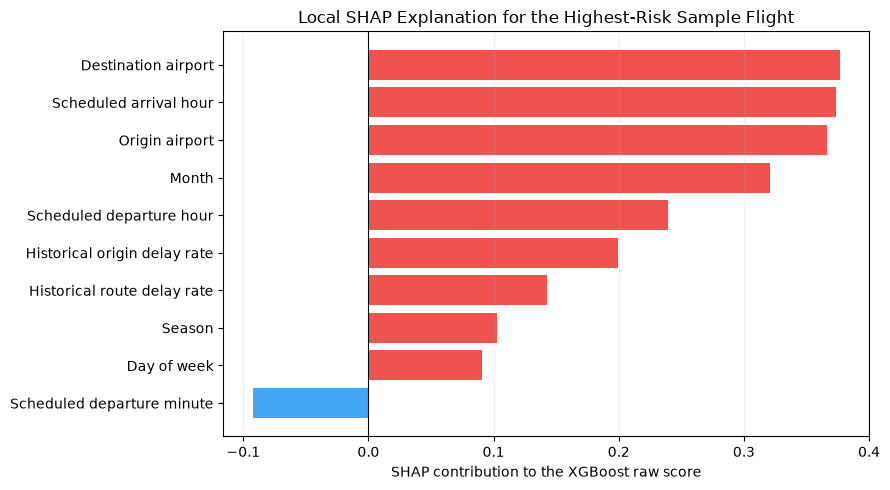

In [15]:
local_row_index = int(np.argmax(delay_probabilities))
local_values = aggregated_shap_values[local_row_index]

local_effects = pd.DataFrame(
    {
        "Feature": [
            FEATURE_LABELS.get(column, column)
            for column in MODEL_COLUMNS
        ],
        "FeatureColumn": MODEL_COLUMNS,
        "SHAPValue": local_values,
    }
)
local_effects["AbsoluteSHAP"] = local_effects["SHAPValue"].abs()
local_effects = local_effects.sort_values(
    "AbsoluteSHAP",
    ascending=False,
    ignore_index=True,
)

local_record = explanation_pdf.iloc[local_row_index]
local_probability = float(delay_probabilities[local_row_index])
local_prediction = int(predicted_labels[local_row_index])
local_actual = int(actual_labels[local_row_index])

local_summary = pd.DataFrame(
    [
        {
            "FlightDate": str(local_record[DATE_COLUMN]),
            "Airline": str(local_record[cfg.AIRLINE_COLUMN]),
            "FlightNumber": int(local_record[cfg.FLIGHT_NUMBER_COLUMN]),
            "Origin": str(local_record[cfg.ORIGIN_COLUMN]),
            "Destination": str(local_record[cfg.DESTINATION_COLUMN]),
            "DelayProbability": local_probability,
            "DecisionThreshold": DECISION_THRESHOLD,
            "PredictedClass": local_prediction,
            "ActualClass": local_actual,
        }
    ]
)

display(local_summary)
display(local_effects.head(10))

local_plot = local_effects.head(10).sort_values(
    "SHAPValue",
    ascending=True,
)
colors = np.where(
    local_plot["SHAPValue"] >= 0,
    "#ef5350",
    "#42a5f5",
)
fig, axis = plt.subplots(figsize=(9, 5))
axis.barh(
    local_plot["Feature"],
    local_plot["SHAPValue"],
    color=colors,
)
axis.axvline(0, color="black", linewidth=0.8)
axis.set_title("Local SHAP Explanation for the Highest-Risk Sample Flight")
axis.set_xlabel("SHAP contribution to the XGBoost raw score")
axis.set_ylabel("")
axis.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

top_positive = (
    local_effects[local_effects["SHAPValue"] > 0]
    .sort_values("SHAPValue", ascending=False)
    .head(5)[["Feature", "FeatureColumn", "SHAPValue"]]
)
top_negative = (
    local_effects[local_effects["SHAPValue"] < 0]
    .sort_values("SHAPValue", ascending=True)
    .head(5)[["Feature", "FeatureColumn", "SHAPValue"]]
)

base_values = np.asarray(shap_explanation.base_values)
flattened_base_values = base_values.reshape(-1)
local_base_value = float(
    flattened_base_values[local_row_index]
    if flattened_base_values.size > 1
    else flattened_base_values[0]
)
local_base_probability = float(1.0 / (1.0 + np.exp(-local_base_value)))

local_explanation_payload = {
    "model_name": MODEL_NAME,
    "row_index": local_row_index,
    "flight_date": str(local_record[DATE_COLUMN]),
    "airline": str(local_record[cfg.AIRLINE_COLUMN]),
    "flight_number": int(local_record[cfg.FLIGHT_NUMBER_COLUMN]),
    "origin": str(local_record[cfg.ORIGIN_COLUMN]),
    "destination": str(local_record[cfg.DESTINATION_COLUMN]),
    "decision_threshold": DECISION_THRESHOLD,
    "delay_probability": local_probability,
    "predicted_class": local_prediction,
    "actual_class": local_actual,
    "shap_output_scale": "XGBoost raw score (log-odds)",
    "base_value": local_base_value,
    "base_probability": local_base_probability,
    "top_positive_features": top_positive.to_dict(orient="records"),
    "top_negative_features": top_negative.to_dict(orient="records"),
}

local_top_effects = local_effects.head(10).copy()
local_top_effects["rank"] = np.arange(1, len(local_top_effects) + 1)
local_explanation_table = local_top_effects.rename(
    columns={
        "Feature": "feature",
        "FeatureColumn": "feature_column",
        "SHAPValue": "shap_value",
        "AbsoluteSHAP": "absolute_shap",
    }
).assign(
    model_name=MODEL_NAME,
    row_index=local_row_index,
    flight_date=str(local_record[DATE_COLUMN]),
    airline=str(local_record[cfg.AIRLINE_COLUMN]),
    flight_number=int(local_record[cfg.FLIGHT_NUMBER_COLUMN]),
    origin=str(local_record[cfg.ORIGIN_COLUMN]),
    destination=str(local_record[cfg.DESTINATION_COLUMN]),
    decision_threshold=DECISION_THRESHOLD,
    delay_probability=local_probability,
    predicted_class=local_prediction,
    actual_class=local_actual,
    shap_output_scale="XGBoost raw score (log-odds)",
    base_value=local_base_value,
    base_probability=local_base_probability,
)
local_explanation_table["effect_direction"] = np.where(
    local_explanation_table["shap_value"] >= 0,
    "Increases risk",
    "Decreases risk",
)
local_explanation_table = local_explanation_table[
    [
        "model_name", "row_index", "flight_date", "airline",
        "flight_number", "origin", "destination",
        "decision_threshold", "delay_probability",
        "predicted_class", "actual_class", "shap_output_scale",
        "base_value", "base_probability", "rank", "feature",
        "feature_column", "shap_value", "absolute_shap",
        "effect_direction",
    ]
]


## Save Explainability Artifacts

The output schemas required by the downstream notebooks are preserved. Global, directional, sampled, and local SHAP results are persisted as tables so downstream notebooks and the API use the same SQL access pattern. The local JSON is retained as a portable artifact.


In [16]:
def write_pandas_table(
    frame: pd.DataFrame,
    table_name: str,
) -> None:
    clean = frame.copy()
    for column in clean.select_dtypes(include=["object"]).columns:
        clean[column] = clean[column].fillna("").astype(str)
    (
        spark.createDataFrame(clean)
        .write.format("delta")
        .mode("overwrite")
        .option("overwriteSchema", "true")
        .saveAsTable(table_name)
    )


write_pandas_table(
    feature_importance,
    cfg.SHAP_GLOBAL_IMPORTANCE_TABLE,
)
write_pandas_table(
    direction_of_effects,
    cfg.SHAP_DIRECTION_EFFECTS_TABLE,
)
write_pandas_table(
    local_explanation_table,
    cfg.SHAP_LOCAL_EXPLANATION_TABLE,
)

top_feature_columns = (
    feature_importance
    .head(cfg.SHAP_VALUES_TOP_FEATURES)["FeatureColumn"]
    .tolist()
)
feature_position = {
    column: index
    for index, column in enumerate(MODEL_COLUMNS)
}
sample_row_count = min(
    cfg.SHAP_VALUES_SAMPLE_ROWS,
    aggregated_shap_values.shape[0],
)

shap_sample_rows = []
for row_index in range(sample_row_count):
    for feature_column in top_feature_columns:
        shap_sample_rows.append(
            {
                "row_index": int(row_index),
                "feature": FEATURE_LABELS.get(
                    feature_column,
                    feature_column,
                ),
                "shap_value": float(
                    aggregated_shap_values[
                        row_index,
                        feature_position[feature_column],
                    ]
                ),
            }
        )

write_pandas_table(
    pd.DataFrame(shap_sample_rows),
    cfg.SHAP_VALUES_SAMPLE_TABLE,
)

client.files.create_directory(cfg.SHAP_ARTIFACTS_PATH)
local_content = json.dumps(
    local_explanation_payload,
    indent=2,
    sort_keys=True,
).encode("utf-8")
client.files.upload(
    cfg.SHAP_LOCAL_EXPLANATION_PATH,
    io.BytesIO(local_content),
    overwrite=True,
)

print("Final XGBoost SHAP artifacts saved successfully.")
print(f"Global importance: {cfg.SHAP_GLOBAL_IMPORTANCE_TABLE}")
print(f"Direction effects: {cfg.SHAP_DIRECTION_EFFECTS_TABLE}")
print(f"SHAP sample: {cfg.SHAP_VALUES_SAMPLE_TABLE}")
print(f"Local explanation table: {cfg.SHAP_LOCAL_EXPLANATION_TABLE}")
print(f"Local explanation: {cfg.SHAP_LOCAL_EXPLANATION_PATH}")


Final XGBoost SHAP artifacts saved successfully.
Global importance: workspace.default.flight_delay_shap_global_importance
Direction effects: workspace.default.flight_delay_shap_direction_effects
SHAP sample: workspace.default.flight_delay_shap_values_sample
Local explanation table: workspace.default.flight_delay_shap_local_explanation
Local explanation: /Volumes/workspace/default/flight_delay_capstone/models/shap_artifacts/local_explanation.json


## RQ2 and RQ4 Conclusions

- **RQ2 contribution:** Global SHAP ranks the schedule-time variables the final
  model actually uses. This complements the statistical associations in
  Notebook 05, but it does not establish causation.
- **RQ4 answer:** Global TreeSHAP explains which factors drive the model overall,
  while the local explanation shows which factors raised or lowered one
  individual flight's prediction. The explanations come from the exact final
  XGBoost model evaluated in Notebook 08, not from text matching or a surrogate
  model.

RQ4 is therefore supported as a transparency demonstration. The project does
not claim that SHAP improves predictive accuracy or user decisions because no
separate user study was conducted.
